In [1]:
# analyse_soap.py
from pathlib import Path
import random

import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import hdbscan                     
import matplotlib.pyplot as plt
from src.data_utils.data_load import SoapCoordDataset   # ← your dataset class
import warnings
warnings.filterwarnings("ignore")


PARQUET_DIR   = Path("datasets/Al/soap_features")
BATCH_SIZE    = 4096
NUM_COMPONENTS = 16
KMEANS_K       = 5
SAMPLE = 100000          # number of points to subsample


parquet_files = sorted(PARQUET_DIR.glob("*_selected.parquet"))
print("Found", len(parquet_files), "files")

dataset = SoapCoordDataset(
    parquet_files,
)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4,)

soap_arrs = []
for soap, _coords in loader:
    soap_arrs.append(soap)      
        
soap_full = torch.cat(soap_arrs, dim=0).numpy()

N = soap_full.shape[0]
subset_size = min(SAMPLE, N)
subset_idx = random.sample(range(N), subset_size)
soap_subset = soap_full[subset_idx]



Found 6 files
SOAP dataset in preload mode


Loaded 826310 SOAP vectors; each has 252 features

PCA(16) explains:
  PC 1:  66.71%  (cumulative  66.71%)
  PC 2:  19.42%  (cumulative  86.13%)
  PC 3:   6.13%  (cumulative  92.26%)
  PC 4:   2.97%  (cumulative  95.24%)
  PC 5:   1.55%  (cumulative  96.79%)
  PC 6:   1.06%  (cumulative  97.85%)
  PC 7:   0.62%  (cumulative  98.48%)
  PC 8:   0.31%  (cumulative  98.79%)
  PC 9:   0.24%  (cumulative  99.04%)
  PC10:   0.19%  (cumulative  99.22%)
  PC11:   0.12%  (cumulative  99.35%)
  PC12:   0.10%  (cumulative  99.45%)
  PC13:   0.09%  (cumulative  99.54%)
  PC14:   0.07%  (cumulative  99.61%)
  PC15:   0.05%  (cumulative  99.66%)
  PC16:   0.04%  (cumulative  99.70%)
Total variance captured by 16 components: 99.70%


Text(0.5, 1.0, 'PCA of SOAP Vectors')

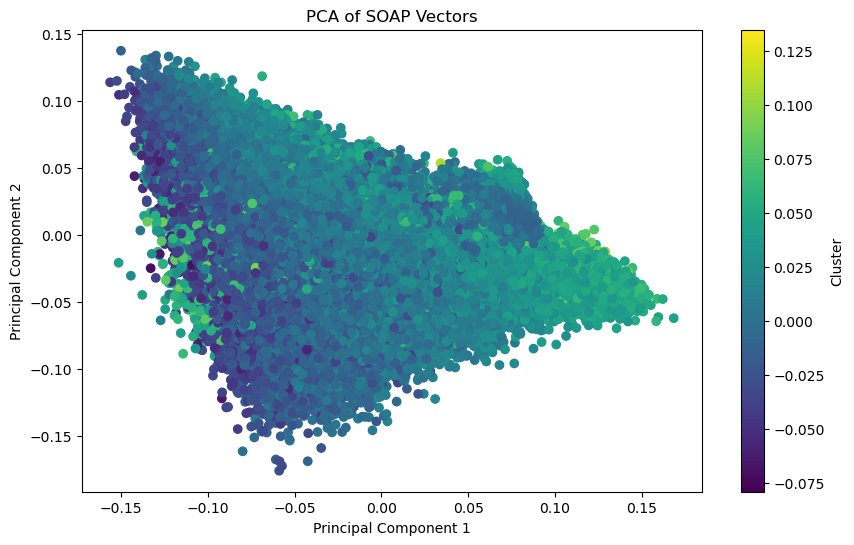

In [2]:
print("Loaded", soap_full.shape[0], "SOAP vectors;"
      f" each has {soap_full.shape[1]} features")

pca = PCA(n_components=NUM_COMPONENTS, svd_solver="full", random_state=0)
soap_pca = pca.fit_transform(soap_subset)

var = pca.explained_variance_ratio_
cum = np.cumsum(var)
print("\nPCA(16) explains:")
for i, v in enumerate(var, 1):
    print(f"  PC{i:2d}: {v*100:6.2f}%  (cumulative {cum[i-1]*100:6.2f}%)")
print(f"Total variance captured by 16 components: {cum[-1]*100:.2f}%")

# Plot PCA
plt.figure(figsize=(10, 6))
plt.scatter(soap_pca[:, 0], soap_pca[:, 1], c=soap_pca[:, 2], cmap='viridis')
plt.colorbar(label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of SOAP Vectors')

HDBSCAN clusters: 6 noise: 84331


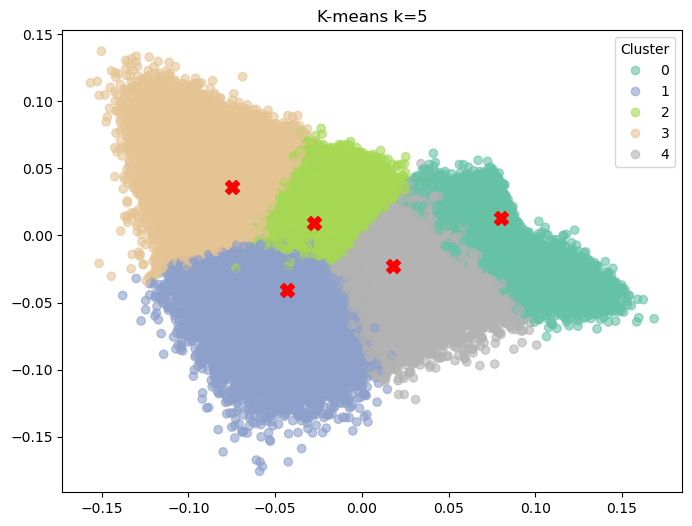

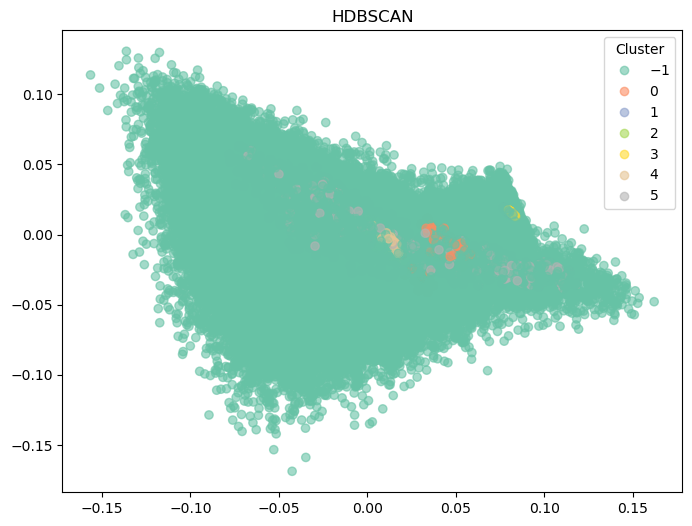

In [3]:

kmeans = KMeans(n_clusters=KMEANS_K, n_init="auto", random_state=0).fit(soap_pca)
labels_km, centers = kmeans.labels_, kmeans.cluster_centers_


HDBSCAN_SAMPLE = 30000
subset = soap_pca[np.random.choice(len(soap_pca), min(HDBSCAN_SAMPLE, len(soap_pca)), replace=False)]
labels_hdb = hdbscan.HDBSCAN(min_cluster_size=300, min_samples=70, metric="euclidean").fit_predict(subset)
print("HDBSCAN clusters:", len(set(labels_hdb)) - (1 in labels_hdb),
      "noise:", np.sum(labels_hdb == -1))

def plot_clusters(data, labels, centers=None, title=''):
    plt.figure(figsize=(8,6))
    sc = plt.scatter(data[:,0], data[:,1], c=labels, cmap='Set2', alpha=0.6)
    if centers is not None:
        plt.scatter(centers[:,0], centers[:,1], c='r', marker='X', s=100)
    plt.title(title)
    plt.legend(*sc.legend_elements(), title='Cluster')
    plt.show()

plot_clusters(soap_pca, labels_km, centers, f'K-means k={KMEANS_K}')
plot_clusters(subset, labels_hdb, title='HDBSCAN')

In [ ]:
from sklearn.manifold import TSNE

kmeans = KMeans(n_clusters=KMEANS_K, random_state=43).fit(soap_pca)
labels_km, centers_pca = kmeans.labels_, kmeans.cluster_centers_

HDBSCAN_SAMPLE = 30000
subset_indices = np.random.choice(len(soap_pca), min(HDBSCAN_SAMPLE, len(soap_pca)), replace=False)
subset_for_hdbscan = soap_pca[subset_indices]
labels_hdb = hdbscan.HDBSCAN(min_cluster_size=400, min_samples=70, metric="euclidean").fit_predict(subset_for_hdbscan)

num_hdb_clusters = len(set(l for l in labels_hdb if l != -1))
print("HDBSCAN clusters:", num_hdb_clusters,
      "noise:", np.sum(labels_hdb == -1))

print("Running t-SNE transformation for plotting...")
tsne_transformer = TSNE(n_components=2, random_state=0, perplexity=30, n_iter=1000) # Common parameters

data_tsne = tsne_transformer.fit_transform(soap_pca)
print("t-SNE transformation complete.")

def plot_clusters(data, labels, centers=None, title=''):
    plt.figure(figsize=(8,6))
    sc = plt.scatter(data[:,0], data[:,1], c=labels, cmap='Set2', alpha=0.6, s=10)
    if centers is not None:
        plt.scatter(centers[:,0], centers[:,1], c='r', marker='X', s=100)
    plt.title(title)
    unique_labels = np.unique(labels)
  
    plt.legend(*sc.legend_elements(), title='Cluster')
    

    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()


plot_clusters(data_tsne, labels_km, centers=None, title=f'K-means (k={KMEANS_K}) on t-SNE plot')

subset_tsne = data_tsne[subset_indices]
plot_clusters(subset_tsne, labels_hdb, title='HDBSCAN on t-SNE plot')

HDBSCAN clusters: 8 noise: 165645
Running t-SNE transformation for plotting...


In [ ]:
# from src.eval_tools.prediction import predict_clusters_pca

def predict_clusters_pca(eval_dataloader,
                        fitted_pca,
                        fitted_kmeans=None,
                        clustering_type: str = "kmeans",
                        hdbscan_params: dict = None) -> np.ndarray:
    """
    Applies fitted PCA transformation and predicts cluster assignments for samples 
    from eval_dataloader.
    """
    
    def extract_soap_and_coords(dataloader):
        """Helper function to extract SOAP features and coordinates from a dataloader."""
        soap_list = []
        coords_list = []
        
        for soap_batch, coords_batch in dataloader:
            soap_list.append(soap_batch.numpy())
            coords_list.append(coords_batch.numpy())
        
        return soap_list, coords_list
    
    print("Extracting SOAP features from eval dataloader...")
    eval_soap_list, eval_coords_list = extract_soap_and_coords(eval_dataloader)
    
    if not eval_soap_list:
        return np.empty((0, 4))
    
    # Concatenate all eval SOAP features and coordinates
    eval_soap = np.concatenate(eval_soap_list, axis=0)
    eval_coords = np.concatenate(eval_coords_list, axis=0)
    
    # Transform eval SOAP features using fitted PCA
    print(f"Transforming {eval_soap.shape[0]} eval samples using fitted PCA...")
    eval_pca_features = fitted_pca.transform(eval_soap)
    
    # Predict cluster assignments based on clustering type
    if clustering_type.lower() == "kmeans":
        if fitted_kmeans is None:
            raise ValueError("fitted_kmeans is required when clustering_type='kmeans'")
        print(f"Predicting cluster assignments using fitted KMeans...")
        cluster_labels = fitted_kmeans.predict(eval_pca_features)
        
    elif clustering_type.lower() == "hdbscan":
        print(f"Fitting HDBSCAN and predicting cluster assignments...")
        
        if hdbscan_params is None:
            hdbscan_params = {"min_cluster_size": 800, "min_samples": 100}
        
        hdbscan_model = hdbscan.HDBSCAN(**hdbscan_params)
        cluster_labels = hdbscan_model.fit_predict(eval_pca_features)
        
        print(f"HDBSCAN found {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)} clusters")
        if -1 in cluster_labels:
            noise_count = sum(1 for label in cluster_labels if label == -1)
            print(f"HDBSCAN identified {noise_count} noise points")
    else:
        raise ValueError(f"Unsupported clustering_type: {clustering_type}. Use 'kmeans' or 'hdbscan'.")
    
    # Combine coordinates and cluster labels for eval samples
    output_data = []
    for i in range(eval_coords.shape[0]):
        coord = eval_coords[i]  # [x, y, z]
        label = cluster_labels[i]  # cluster_id (integer, -1 for noise in HDBSCAN)
        output_data.append([coord[0], coord[1], coord[2], label])

    return np.array(output_data)

from src.eval_tools.vis_utils import visualize_cluster_predictions

dataset = SoapCoordDataset(
    ['datasets/Al/soap_features/175ps_selected.parquet'],
)
eval_dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4,)

prediction = predict_clusters_pca(eval_dataloader=eval_dataloader,
                                   fitted_pca=pca,
                                   fitted_kmeans=kmeans,
                                   clustering_type="hdbscan"
                                   )
visualize_cluster_predictions(prediction,
                             alphas = [0.05, 0.8, 0.8, 0.5, 0.5, 0.85, 0.85, 0.85],
                             colors = [ '#FF0000',  # Red
                                        '#00FFFF',  # Cyan
                                        '#0000FF',  # Blue
                                        '#FFFF00',  # Yellow
                                        '#FF00FF',  # Magenta
                                        '#FFA500',  # Orange
                                        '#00FF00',  # Lime Green
                                        '#800080',  # Purple
                                        ],)

SOAP dataset in preload mode
Extracting SOAP features from eval dataloader...
Transforming 143312 eval samples using fitted PCA...
Fitting HDBSCAN and predicting cluster assignments...
